# IT Support Ticket Classifier: EDA & Preprocessing

**Dataset:** [Console-AI/IT-helpdesk-synthetic-tickets](https://huggingface.co/datasets/Console-AI/IT-helpdesk-synthetic-tickets) (MIT license, ~500 synthetic internal IT tickets)

In [15]:
# SETUP
#   'colab_drive' -> Colab, saving to Google Drive (persists across sessions)
#   'colab_local' -> Colab, saving to the ephemeral VM disk (gone on disconnect)
#   'local'       -> VS Code / local Jupyter, saving into your repo's data/ folder
RUN_MODE = 'local'

import os

if RUN_MODE == 'colab_drive':
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/it-ticket-classifier'
elif RUN_MODE == 'colab_local':
    PROJECT_DIR = '/content'
else:  # local
    PROJECT_DIR = os.path.abspath('../data')

os.makedirs(PROJECT_DIR, exist_ok=True)
print(f"Project directory: {PROJECT_DIR}")


Project directory: c:\Users\jysob\Desktop\aig-ticketclass\data


In [16]:
!pip install -q datasets pandas numpy matplotlib seaborn scikit-learn


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

from datasets import load_dataset
from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")
pd.set_option('display.max_colwidth', 100)


## 1. Load dataset

In [18]:
raw = load_dataset("Console-AI/IT-helpdesk-synthetic-tickets")
print(raw)

df = raw["train"].to_pandas()
print(f"\nShape: {df.shape}")
df.head()


DatasetDict({
    train: Dataset({
        features: ['id', 'subject', 'description', 'priority', 'category', 'createdAt', 'requesterEmail'],
        num_rows: 500
    })
})

Shape: (500, 7)


,id,subject,description,priority,category,createdAt,requesterEmail
0,1aiu3lrqi,Hey IT! Our network printer keeps disconnecting.,Hey IT! Our network printer keeps disconnecting intermittently and requires manual IP reconfigur...,Medium,Network,2024-10-28T18:36:55.004Z,jane.doe@acme.co
1,kz5mjjpox,Re: [Acme IT] Re: Ticket #98765 - Access Issue with Shared Network Drive,"This is a follow-up to your previous request #98765 ""Access Issue with Shared Network Drive""\n\n...",High,Network,2024-10-28T18:36:56.156Z,user123@acme.co
2,86eza0fwq,Software Conflict Causing App Crashes,Hey team! :wave: We're experiencing some intermittent crashes on specific user machines. It seem...,High,Software,2024-10-28T18:36:54.644Z,user@acme.co
3,jtw509e3n,j.doe@acme.co Google Calendar Setup Assistance,We need to set up a new Google Calendar for team scheduling. Please assist with the following st...,Medium,Software,2024-10-28T18:36:54.524Z,j.doe@acme.co
4,tso616mbn,Software Access: Asana Project for Jordan Smith,Jordan Smith is part of the Project Management team and requires access to the Asana project to ...,Medium,Software,2024-10-28T18:36:54.816Z,jordan.smith@acme.co


## 2. Basic structure

In [19]:
print("Columns:", list(df.columns))
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nDtypes:")
print(df.dtypes)


Columns: ['id', 'subject', 'description', 'priority', 'category', 'createdAt', 'requesterEmail']

Missing values per column:
id                0
subject           0
description       0
priority          0
category          0
createdAt         0
requesterEmail    0
dtype: int64

Dtypes:
id                object
subject           object
description       object
priority          object
category          object
createdAt         object
requesterEmail    object
dtype: object


## 3. Category distribution

category
Software          231
Account            71
Network            68
Security           42
Communication      24
Hardware           22
RemoteWork         20
Training           12
Infrastructure      7
Licensing           2
Performance         1
Name: count, dtype: int64


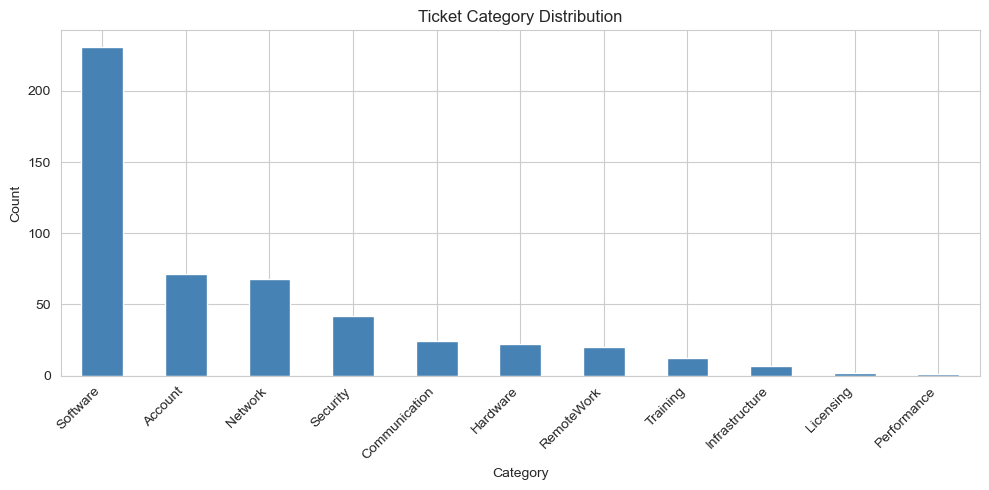


Number of categories: 11
Smallest category: Performance (1 tickets)
Largest category: Software (231 tickets)


In [20]:
category_counts = df['category'].value_counts()
print(category_counts)

plt.figure(figsize=(10, 5))
category_counts.plot(kind='bar', color='steelblue')
plt.title('Ticket Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nNumber of categories: {df['category'].nunique()}")
print(f"Smallest category: {category_counts.idxmin()} ({category_counts.min()} tickets)")
print(f"Largest category: {category_counts.idxmax()} ({category_counts.max()} tickets)")


Note: Category imbalance significant. Categories can be merged later. We can note that there's a big drop from 20 (RemoteWork) and 12 (Training), and a continuous decrease after that. 

## 4. Priority distribution

priority
Medium    293
High      199
Low         4
Urgent      4
Name: count, dtype: int64


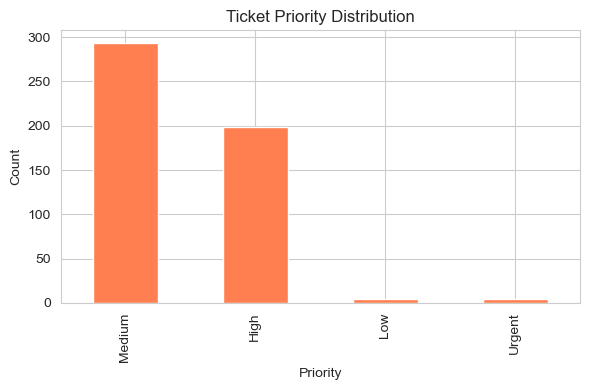

In [21]:
priority_counts = df['priority'].value_counts()
print(priority_counts)

plt.figure(figsize=(6, 4))
priority_counts.plot(kind='bar', color='coral')
plt.title('Ticket Priority Distribution')
plt.xlabel('Priority')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


## 5. Text length analysis

count    500.000000
mean      66.476000
std       58.564572
min        9.000000
25%       34.000000
50%       52.000000
75%       74.000000
max      614.000000
Name: word_count, dtype: float64


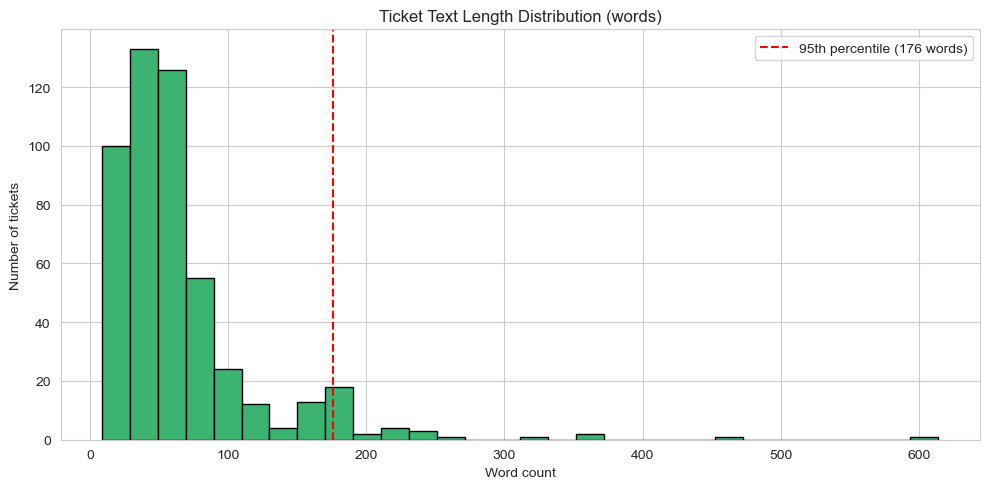


95th percentile word count: 176.


In [22]:
df['full_text'] = df['subject'].fillna('') + ". " + df['description'].fillna('')
df['word_count'] = df['full_text'].apply(lambda x: len(x.split()))

print(df['word_count'].describe())

p95 = int(df['word_count'].quantile(0.95))

plt.figure(figsize=(10, 5))
plt.hist(df['word_count'], bins=30, color='mediumseagreen', edgecolor='black')
plt.axvline(p95, color='red', linestyle='--', label=f'95th percentile ({p95} words)')
plt.title('Ticket Text Length Distribution (words)')
plt.xlabel('Word count')
plt.ylabel('Number of tickets')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n95th percentile word count: {p95}.")

Note: 95th percentile of the tokenized training text will be used as actual measure.

## 6. Vocabulary characteristics

In [23]:
all_words = " ".join(df['full_text'].str.lower()).split()
all_words = [re.sub(r'[^a-z0-9]', '', w) for w in all_words]
all_words = [w for w in all_words if w]

vocab = set(all_words)
print(f"Total tokens: {len(all_words)}")
print(f"Unique vocabulary size: {len(vocab)}")

word_freq = Counter(all_words)
print("\nTop 20 most common words:")
for word, count in word_freq.most_common(20):
    print(f"  {word}: {count}")


Total tokens: 32510
Unique vocabulary size: 2461

Top 20 most common words:
  to: 1099
  the: 1064
  you: 622
  and: 594
  access: 524
  this: 501
  for: 496
  it: 452
  a: 380
  with: 350
  on: 336
  request: 311
  please: 299
  i: 290
  acme: 283
  of: 250
  email: 249
  in: 244
  team: 243
  issues: 229


## 7. Duplicate / templated ticket check


In [24]:
exact_dupes = df['description'].duplicated().sum()
print(f"Exact duplicate descriptions: {exact_dupes}")

# Rough near-duplicate: tickets sharing the same opening 6 words
df['first_6_words'] = df['full_text'].apply(lambda x: ' '.join(x.split()[:6]))
template_counts = df['first_6_words'].value_counts()
repeated = template_counts[template_counts > 1]

print(f"\nTickets sharing an opening phrase with at least one other ticket: {repeated.sum()}")
print("\nMost repeated openings:")
print(repeated.head(10))


Exact duplicate descriptions: 3

Tickets sharing an opening phrase with at least one other ticket: 22

Most repeated openings:
first_6_words
Assistance Required for Configuring Multi-Factor Authentication.    5
Assistance Required for Configuring New Hire's                      3
Instructions for Creating a New Google                              2
Persistent Slow Internet Connection on Workstation.                 2
Assistance Required for Troubleshooting Persistent Slow             2
Alert: Persistent Slow Internet Connection on                       2
Accessing Shared Network Drive. Hi IT                               2
Assistance Required for Investigating and Resolving                 2
Instructions for Configuring Company Email on                       2
Name: count, dtype: int64


## 8. Handling rare categories ("Others")


Categories below threshold (20): ['Training', 'Infrastructure', 'Licensing', 'Performance']

Final category distribution after merging:
category_final
Software         231
Account           71
Network           68
Security          42
Communication     24
Other             22
Hardware          22
RemoteWork        20
Name: count, dtype: int64


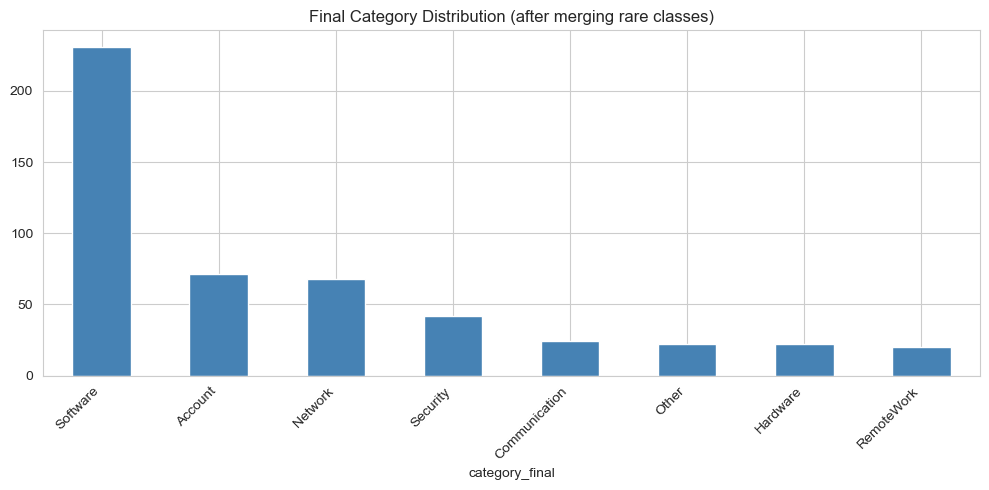

In [25]:
MIN_CATEGORY_COUNT = 20  # based on gap in counts

rare_categories = category_counts[category_counts < MIN_CATEGORY_COUNT].index.tolist()
print(f"Categories below threshold ({MIN_CATEGORY_COUNT}): {rare_categories}")

df['category_final'] = df['category'].apply(
    lambda c: 'Other' if c in rare_categories else c
)

final_counts = df['category_final'].value_counts()
print("\nFinal category distribution after merging:")
print(final_counts)

plt.figure(figsize=(10, 5))
final_counts.plot(kind='bar', color='steelblue')
plt.title('Final Category Distribution (after merging rare classes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 9. Stratified train/val/test split


In [26]:
LABEL_COL = 'category_final'

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df[LABEL_COL], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df[LABEL_COL], random_state=42
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

print("\nClass balance check:")
comparison = pd.DataFrame({
    'train': train_df[LABEL_COL].value_counts(normalize=True),
    'val': val_df[LABEL_COL].value_counts(normalize=True),
    'test': test_df[LABEL_COL].value_counts(normalize=True),
}).fillna(0)
print(comparison.round(3))


Train: 350 | Val: 75 | Test: 75

Class balance check:
                train    val   test
category_final                     
Account         0.143  0.147  0.133
Communication   0.049  0.040  0.053
Hardware        0.043  0.053  0.040
Network         0.137  0.133  0.133
Other           0.043  0.040  0.053
RemoteWork      0.040  0.040  0.040
Security        0.083  0.080  0.093
Software        0.463  0.467  0.453


## 10. Save splits


In [27]:
output_cols = ['subject', 'description', 'full_text', 'category_final', 'priority']

train_df[output_cols].to_csv(f"{PROJECT_DIR}/train.csv", index=False)
val_df[output_cols].to_csv(f"{PROJECT_DIR}/val.csv", index=False)
test_df[output_cols].to_csv(f"{PROJECT_DIR}/test.csv", index=False)

print(f"Saved train.csv, val.csv, test.csv to {PROJECT_DIR}")

if RUN_MODE == 'colab_local':
    print("\nRUN_MODE is 'colab_local'. These files live only in this Colab session's disk.")
elif RUN_MODE == 'local':
    print(f"\nSaved into your repo's data/ folder.")


Saved train.csv, val.csv, test.csv to c:\Users\jysob\Desktop\aig-ticketclass\data

Saved into your repo's data/ folder.
